# 딥러닝 응용 오토인코더 기반 이상 탐지

## 학습 목표

1. **오토인코더 구조 이해** 인코더-잠재공간-디코더 아키텍처의 원리를 파악
2. **Keras 구현** Sequential API로 오토인코더를 구성하고 학습
3. **이상 탐지 적용** | 재구성 오차 기반 이상 탐지 기법을 실무에 적용

# 1: 오토인코더 개념

---

## 1.1 오토인코더란 무엇인가?

**오토인코더(Autoencoder)** 는 입력 데이터를 **압축**한 후 다시 **복원**하여 **입력 자체를 재구성**하도록 학습하는 비지도 학습 기반의 신경망 구조임.
"자동으로 인코딩한다"는 의미에서 오토인코더라는 이름이 붙었음.

### 왜 입력을 그대로 복원하는 것을 학습하는가?

일반적인 지도 학습에서는 입력 $X$가 주어지면 정답 $Y$를 예측하도록 학습함. 
하지만 오토인코더는 **입력 $X$를 받아서 다시 $X$를 출력**하도록 학습함. 얼핏 보면 무의미해 보이지만, 핵심은 **중간에 정보를 압축하는 병목(Bottleneck) 구간**이 있다는 점임.

```
[일반적인 지도 학습]
입력 X (10차원) --> 신경망 --> 출력 Y (클래스 라벨)

[오토인코더]
입력 X (10차원) --> 압축(3차원) --> 복원 --> 출력 X' (10차원)
                     ^
                     |
              병목(Bottleneck)
              핵심 정보만 남김
```

10차원의 데이터를 3차원으로 압축했다가 다시 10차원으로 복원해야 하므로, 모델은 **가장 중요한 정보만 선별하여 기어ㄱ**하는 방법을 스스로 학습하게 됨. 이것이 오토인코더의 핵심 아이디어임.

## 1.2 오토인코더의 구조

오토인코더는 크게 세 부분으로 구성됨:

```mermaid
flowchart LR
    subgraph Encoder["인코더 (Encoder)"]
        X["입력 X<br/>(10차원)"] --> H1["은닉층<br/>(8노드)"]
        H1 --> H2["은닉층<br/>(5노드)"]
        H2 --> Z["잠재 벡터 z<br/>(3차원)"]
    end

    subgraph Bottleneck["병목"]
        Z
    end

    subgraph Decoder["디코더 (Decoder)"]
        Z --> H3["은닉층<br/>(5노드)"]
        H3 --> H4["은닉층<br/>(8노드)"]
        H4 --> X_hat["출력 X'<br/>(10차원)"]
    end

    style Z fill:#ff6b6b,stroke:#333,stroke-width:2px
    style X fill:#4ecdc4,stroke:#333
    style X_hat fill:#45b7d1,stroke:#333
```

| 구성요소 | 역할 | 차원 변화 예시 |
|:---:|:---|:---:|
| **인코더(Encoder)** | 입력 데이터를 저차원 잠재 공간으로 압축 | 10 → 8 → 5 → 3 |
| **잠재 공간(Latent Space)** | 핵심 특징만 남긴 압축된 표현 (병목) | 3차원 |
| **디코더(Decoder)** | 잠재 공간에서 원래 차원으로 복원 | 3 → 5 → 8 → 10 |

### 구조의 특징

1. **대칭 구조**: 인코더와 디코더는 보통 대칭적인 구조를 가짐
2. **점진적 압축/복원**: 한 번에 크게 줄이지 않고 단계적으로 차원을 변화시킴
3. **병목(Bottleneck)**: 가운데 가장 작은 차원이 정보 압축의 핵심

## 1.3 개념적 정의

오토인코더의 동작을 수학적으로 정의하면 다음과 같음.

### 인코더 함수 (Encoder Function)

인코더는 입력 $\mathbf{x}$를 잠재 벡터 $\mathbf{z}$로 변환하는 함수 $f$임:

$$\mathbf{z} = f(\mathbf{x}) = \sigma(\mathbf{W}_e \mathbf{x} + \mathbf{b}_e)$$

| 기호 | 의미 | 설명 |
|:---:|:---|:---|
| $\mathbf{x}$ | 입력 벡터 | 원본 데이터 (예: 10차원 센서 값) |
| $\mathbf{z}$ | 잠재 벡터 | 압축된 표현 (예: 3차원) |
| $\mathbf{W}_e$ | 인코더 가중치 행렬 | 학습되는 파라미터 |
| $\mathbf{b}_e$ | 인코더 편향 벡터 | 학습되는 파라미터 |
| $\sigma$ | 활성화 함수 | ReLU, sigmoid 등 비선형 함수 |

### 디코더 함수 (Decoder Function)

디코더는 잠재 벡터 $\mathbf{z}$에서 원본을 복원하는 함수 $g$임:

$$\hat{\mathbf{x}} = g(\mathbf{z}) = \sigma(\mathbf{W}_d \mathbf{z} + \mathbf{b}_d)$$

| 기호 | 의미 | 설명 |
|:---:|:---|:---|
| $\hat{\mathbf{x}}$ | 재구성된 출력 | 원본과 유사해야 함 |
| $\mathbf{W}_d$ | 디코더 가중치 행렬 | 학습되는 파라미터 |
| $\mathbf{b}_d$ | 디코더 편향 벡터 | 학습되는 파라미터 |

### 목적 함수 (Loss Function)

오토인코더의 학습 목표는 입력과 재구성된 출력 사이의 차이를 최소화하는 것임:

$$\mathcal{L} = \min_{\mathbf{W}_e, \mathbf{W}_d, \mathbf{b}_e, \mathbf{b}_d} \frac{1}{n}\sum_{i=1}^{n}\|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2$$

이를 **재구성 오차(Reconstruction Error)** 또는 **재구성 손실(Reconstruction Loss)** 이라고 부름. 주로 평균 제곱 오차(MSE)를 사용함.

### 수식 전개 예시: 재구성 오차 계산

구체적인 예시를 통해 재구성 오차가 어떻게 계산되는지 살펴보겠음.

**상황**: 3개의 센서 값으로 구성된 1개의 샘플이 있다고 가정

| 센서 | 원본 $x_i$ | 재구성 $\hat{x}_i$ | 오차 $(x_i - \hat{x}_i)$ | 제곱 오차 $(x_i - \hat{x}_i)^2$ |
|:---:|:---:|:---:|:---:|:---:|
| 온도 | 0.80 | 0.78 | 0.02 | 0.0004 |
| 압력 | 0.50 | 0.52 | -0.02 | 0.0004 |
| 진동 | 0.30 | 0.28 | 0.02 | 0.0004 |

**재구성 오차(MSE) 계산**:

$$\text{MSE} = \frac{1}{3}\sum_{i=1}^{3}(x_i - \hat{x}_i)^2 = \frac{0.0004 + 0.0004 + 0.0004}{3} = \frac{0.0012}{3} = 0.0004$$

이 값이 작을수록 원본과 재구성 결과가 유사하다는 의미임. **정상 데이터는 재구성 오차가 작고, 이상 데이터는 재구성 오차가 큼**.

## 1.4 오토인코더를 이용한 이상 탐지 원리

오토인코더 기반 이상 탐지의 핵심 아이디어는 다음과 같음:

```mermaid
flowchart TD
    subgraph Training["학습 단계"]
        A["정상 데이터만 수집"] --> B["오토인코더 학습"]
        B --> C["정상 패턴을 기억"]
    end

    subgraph Detection["탐지 단계"]
        D["새로운 데이터 입력"] --> E["오토인코더로 재구성"]
        E --> F["재구성 오차 계산"]
        F --> G{"오차가 임계값보다 큰가?"}
        G -->|"Yes"| H["이상 (Anomaly)"]
        G -->|"No"| I["정상 (Normal)"]
    end

    C --> D

    style H fill:#e74c3c,stroke:#333
    style I fill:#2ecc71,stroke:#333
    style C fill:#3498db,stroke:#333
```

### 핵심 가정

> **정상 데이터만으로 학습한 오토인코더는 이상 데이터를 제대로 복원하지 못한다.**

이유는 다음과 같음:

1. 오토인코더는 학습 데이터의 패턴을 기억함
2. 정상 데이터만 학습했으므로, 정상 패턴만 잘 복원할 수 있음
3. 이상 데이터는 학습한 적 없는 패턴이므로 제대로 복원하지 못함
4. 따라서 이상 데이터의 재구성 오차는 정상 데이터보다 크게 나타남

### 다른 이상 탐지 방법과의 비교

| 방법 | 장점 | 단점 | 적합한 경우 |
|:---|:---|:---|:---|
| **규칙 기반** | 해석 용이, 구현 간단 | 복잡한 패턴 표현 불가 | 단순한 임계값 기반 감시 |
| **통계 기반 (Z-score)** | 간단, 빠른 계산 | 다변량 관계 표현 어려움 | 단변량 데이터 |
| **Isolation Forest** | 고차원에서 효과적 | 비선형 패턴에 한계 | 정형 데이터 이상 탐지 |
| **오토인코더** | 복잡한 비선형 패턴 학습 | 학습 데이터 필요, 해석 어려움 | 고차원, 복잡한 패턴 |

오토인코더는 특히 **다변량 센서 데이터**에서 센서 간의 복잡한 상호작용을 학습할 수 있어 제조업 이상 탐지에 널리 활용됨.

## 1.5 임계값(Threshold) 설정 방법

재구성 오차가 계산되면, 이를 기준으로 정상/이상을 판정해야 함. 이때 **임계값(Threshold)** 을 설정하는 방법이 중요함.

### 통계적 임계값 설정

정상 데이터의 재구성 오차 분포를 기반으로 임계값을 설정함:

$$\theta = \mu + k \cdot \sigma$$

| 기호 | 의미 | 설명 |
|:---:|:---|:---|
| $\theta$ | 임계값 | 이상 판정 기준 |
| $\mu$ | 평균 | 정상 데이터 재구성 오차의 평균 |
| $\sigma$ | 표준편차 | 정상 데이터 재구성 오차의 표준편차 |
| $k$ | 민감도 상수 | 임계값 조절 파라미터 |

### k 값에 따른 의미 (정규분포 가정 시)

| k 값 | 신뢰구간 | 의미 | 특징 |
|:---:|:---:|:---|:---|
| 1 | 약 68% | 매우 민감한 탐지 | 오탐(False Positive) 많음 |
| 2 | 약 95% | 민감한 탐지 | 균형적 |
| 3 | 약 99.7% | 보수적 탐지 | 미탐(False Negative) 가능 |

### 수식 전개 예시

정상 데이터의 재구성 오차가 다음과 같다고 가정:

- 평균 $\mu = 0.0012$
- 표준편차 $\sigma = 0.0005$

**k=3일 때 임계값 계산**:

$$\theta = 0.0012 + 3 \times 0.0005 = 0.0012 + 0.0015 = 0.0027$$

따라서 재구성 오차가 0.0027보다 크면 이상으로 판정함.

### 판정 규칙

$$\text{판정} = \begin{cases} \text{이상 (Anomaly)} & \text{if } L > \theta \\ \text{정상 (Normal)} & \text{if } L \leq \theta \end{cases}$$

여기서 $L$은 해당 샘플의 재구성 오차임.

# 2: 실습- 데이터 준비 및 모델 구현

## 2.1 실습 데이터 소개: Kaggle Pump Sensor Data

본 실습에서는 **Kaggle의 Pump Sensor Data**를 사용함. 이 데이터셋은 산업용 펌프에 설치된 53개의 센서에서 수집된 실제 운영 데이터임.

### 데이터셋 정보

| 항목 | 내용 |
|:---|:---|
| **출처** | Kaggle (nphantawee/pump-sensor-data) |
| **샘플 수** | 약 220,000건 |
| **센서 수** | 52개 (sensor_00 ~ sensor_51) |
| **라벨** | NORMAL, BROKEN, RECOVERING |
| **활용 목적** | 예측 정비(Predictive Maintenance), 이상 탐지 |

### 실제 활용 시나리오

제조 공장에서 산업용 펌프가 예기치 않게 고장나면 생산 중단과 환경 피해가 발생할 수 있음. 이 데이터셋은 펌프가 고장나기 전에 센서 값의 이상 패턴을 감지하여 **사전에 정비할 수 있도록** 하는 것이 목적임.

## 2.2 환경 설정 및 라이브러리 임포트

In [1]:
# ============================================================
# 라이브러리 임포트
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# TensorFlow 경고 메시지 숨김
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# scikit-learn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 경고 메시지 숨김
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 설정
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow 버전: {tf.__version__}")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

C:\Users\oswar_000\miniconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 버전: 2.20.0
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


In [3]:
# ============================================================
# 데이터 다운로드 (Kaggle API 또는 직접 다운로드)
# ============================================================

# 방법 1: Kaggle API 사용 (설치 필요: pip install kaggle)
# !kaggle datasets download -d nphantawee/pump-sensor-data --unzip

# 방법 2: 직접 다운로드한 경우 파일 경로 지정
# 아래 경로를 실제 파일 위치로 수정하세요
DATA_PATH = 'sensor.csv'

# 데이터가 없는 경우 샘플 URL에서 직접 로드 시도
try:
    df = pd.read_csv(DATA_PATH)
    print(f"로컬 파일에서 데이터 로드 완료: {DATA_PATH}")
except FileNotFoundError:
    print("로컬 파일을 찾을 수 없습니다.")
    print("Kaggle에서 데이터를 다운로드하세요:")
    print("https://www.kaggle.com/datasets/nphantawee/pump-sensor-data")
    print("\n또는 아래 코드를 실행하여 Kaggle API로 다운로드:")
    print("!pip install kaggle")
    print("!kaggle datasets download -d nphantawee/pump-sensor-data --unzip")    

로컬 파일에서 데이터 로드 완료: sensor.csv


In [4]:
# ============================================================
# 데이터 기본 정보 확인
# ============================================================

print("=" * 70)
print("데이터셋 기본 정보")
print("=" * 70)
print(f"\n데이터 형태: {df.shape}")
print(f"  - 총 샘플 수: {df.shape[0]:,}개")
print(f"  - 총 컬럼 수: {df.shape[1]}개")

print("\n컬럼 목록:")
print(df.columns.tolist())

데이터셋 기본 정보

데이터 형태: (220320, 55)
  - 총 샘플 수: 220,320개
  - 총 컬럼 수: 55개

컬럼 목록:
['Unnamed: 0', 'timestamp', 'sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51', 'machine_status']


In [5]:
# ============================================================
# 데이터 미리보기
# ============================================================

print("\n처음 5개 행:")
df.head()


처음 5개 행:


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [6]:
# ============================================================
# 라벨(machine_status) 분포 확인
# ============================================================

print("\n펌프 상태 분포:")
status_counts = df['machine_status'].value_counts()
print(status_counts)

print("\n비율:")
print(df['machine_status'].value_counts(normalize=True).round(4) * 100)


펌프 상태 분포:
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

비율:
machine_status
NORMAL        93.43
RECOVERING     6.57
BROKEN         0.00
Name: proportion, dtype: float64


### 라벨 분포 해석

- **NORMAL**: 펌프가 정상 작동하는 상태
- **BROKEN**: 펌프가 고장난 상태 (이상)
- **RECOVERING**: 펌프가 고장 후 회복 중인 상태 (이상으로 간주)

이상 탐지를 위해 BROKEN과 RECOVERING을 **이상(Anomaly)**으로, NORMAL을 **정상(Normal)**으로 분류함.

In [7]:
# ============================================================
# 결측값 확인
# ============================================================

print("\n결측값 확인:")
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) > 0:
    print(f"결측값이 있는 컬럼 수: {len(missing_cols)}개")
    print("\n결측값 상위 10개 컬럼:")
    print(missing_cols.sort_values(ascending=False).head(10))
else:
    print("결측값 없음")


결측값 확인:
결측값이 있는 컬럼 수: 52개

결측값 상위 10개 컬럼:
sensor_15    220320
sensor_50     77017
sensor_51     15383
sensor_00     10208
sensor_07      5451
sensor_08      5107
sensor_06      4798
sensor_09      4595
sensor_01       369
sensor_30       261
dtype: int64


In [8]:
# ============================================================
# 기초 통계량 확인
# ============================================================

# 센서 컬럼만 선택
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
print(f"\n센서 컬럼 수: {len(sensor_cols)}개")

print("\n센서 데이터 기초 통계량 (상위 10개 센서):")
df[sensor_cols[:10]].describe().round(4)


센서 컬럼 수: 52개

센서 데이터 기초 통계량 (상위 10개 센서):


,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09
count,210112.0000,219951.0000,220301.0000,220301.0000,220301.0000,220301.0000,215522.0000,214869.0000,215213.0000,215725.0000
mean,2.3722,47.5916,50.8674,43.7525,590.6739,73.3964,13.5015,15.8432,15.2007,14.7992
std,0.4122,3.2967,3.6668,2.4189,144.0239,17.2982,2.1637,2.2012,2.0374,2.0920
min,0.0000,0.0000,33.1597,31.6406,2.7980,0.0000,0.0145,0.0000,0.0289,0.0000
25%,2.4388,46.3108,50.3906,42.8385,626.6204,69.9763,13.3464,15.9071,15.1837,15.0535
50%,2.4565,48.1337,51.6493,44.2274,632.6389,75.5768,13.6429,16.1675,15.4948,15.0825
75%,2.4998,49.4792,52.7778,45.3125,637.6157,80.9122,14.5399,16.4280,15.6973,15.1186
max,2.5490,56.7274,56.0330,48.2205,800.0000,99.9999,22.2512,23.5966,24.3490,25.0000


## 2.4 데이터 전처리

오토인코더 학습을 위해 다음과 같은 전처리를 수행함:

1. **결측값 처리**: 센서 데이터의 결측값을 적절히 처리
2. **라벨 변환**: NORMAL → 0, BROKEN/RECOVERING → 1 (이상)
3. **데이터 분할**: 정상 데이터만 학습용, 전체 데이터를 테스트용
4. **정규화**: MinMaxScaler로 0~1 범위로 스케일링

### 왜 정상 데이터만으로 학습하는가?

오토인코더 기반 이상 탐지에서는 **정상 데이터만으로 모델을 학습**함. 그 이유는:

1. 이상 데이터는 다양한 형태로 나타날 수 있어 모든 패턴을 학습하기 어려움
2. 정상 패턴만 학습하면, 학습하지 않은 이상 패턴은 재구성이 잘 되지 않음
3. 이를 통해 "정상이 아닌 모든 것"을 이상으로 탐지할 수 있음

In [9]:
# ============================================================
# 전처리 1: 결측값 처리
# ============================================================

print("=" * 70)
print("전처리 1: 결측값 처리")
print("=" * 70)

# 전처리 전 결측값 확인
missing_before = df[sensor_cols].isnull().sum().sum()
print(f"\n처리 전 총 결측값: {missing_before:,}개")

# 결측값 처리: 컬럼별 중앙값으로 대체
# 중앙값을 사용하는 이유: 이상치에 덜 민감함
df_processed = df.copy()

for col in sensor_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)

# 처리 후 결측값 확인
missing_after = df_processed[sensor_cols].isnull().sum().sum()
print(f"처리 후 총 결측값: {missing_after:,}개")

# sensor_15가 모두 NaN인 경우 (특수 케이스) 제거
cols_to_drop = []
for col in sensor_cols:
    if df_processed[col].std() == 0 or df_processed[col].isna().all():
        cols_to_drop.append(col)
        
if cols_to_drop:
    print(f"\n제거할 컬럼 (분산=0 또는 모두 NaN): {cols_to_drop}")
    df_processed = df_processed.drop(columns=cols_to_drop)
    sensor_cols = [col for col in sensor_cols if col not in cols_to_drop]
    print(f"제거 후 센서 컬럼 수: {len(sensor_cols)}개")

전처리 1: 결측값 처리

처리 전 총 결측값: 344,574개
처리 후 총 결측값: 220,320개

제거할 컬럼 (분산=0 또는 모두 NaN): ['sensor_15']
제거 후 센서 컬럼 수: 51개


In [10]:
# ============================================================
# 전처리 2: 라벨 변환 (이진 분류)
# ============================================================

print("\n" + "=" * 70)
print("전처리 2: 라벨 변환")
print("=" * 70)

# NORMAL → 0 (정상), BROKEN/RECOVERING → 1 (이상)
df_processed['is_anomaly'] = df_processed['machine_status'].apply(
    lambda x: 0 if x == 'NORMAL' else 1
)

print("\n라벨 변환 결과:")
print("  - NORMAL → 0 (정상)")
print("  - BROKEN, RECOVERING → 1 (이상)")

print("\n변환 후 라벨 분포:")
label_counts = df_processed['is_anomaly'].value_counts().sort_index()
print(f"  - 정상 (0): {label_counts[0]:,}개 ({label_counts[0]/len(df_processed)*100:.2f}%)")
print(f"  - 이상 (1): {label_counts[1]:,}개 ({label_counts[1]/len(df_processed)*100:.2f}%)")


전처리 2: 라벨 변환

라벨 변환 결과:
  - NORMAL → 0 (정상)
  - BROKEN, RECOVERING → 1 (이상)

변환 후 라벨 분포:
  - 정상 (0): 205,836개 (93.43%)
  - 이상 (1): 14,484개 (6.57%)


In [11]:
# ============================================================
# 전처리 3: 데이터 분할
# ============================================================

print("\n" + "=" * 70)
print("전처리 3: 데이터 분할")
print("=" * 70)

# 특성(X)과 라벨(y) 분리
X = df_processed[sensor_cols].values
y = df_processed['is_anomaly'].values

print(f"\n전체 데이터 형태: X={X.shape}, y={y.shape}")

# 정상 데이터만 분리 (학습용)
X_normal = X[y == 0]
X_anomaly = X[y == 1]

print(f"\n정상 데이터: {X_normal.shape[0]:,}개")
print(f"이상 데이터: {X_anomaly.shape[0]:,}개")

# 정상 데이터를 학습/검증으로 분할 (80:20)
X_train_normal, X_val_normal = train_test_split(
    X_normal, test_size=0.2, random_state=42
)

print(f"\n학습용 정상 데이터: {X_train_normal.shape[0]:,}개")
print(f"검증용 정상 데이터: {X_val_normal.shape[0]:,}개")

# 테스트 데이터 구성 (검증용 정상 + 이상)
X_test = np.vstack([X_val_normal, X_anomaly])
y_test = np.hstack([np.zeros(len(X_val_normal)), np.ones(len(X_anomaly))])

print(f"\n테스트 데이터: {X_test.shape[0]:,}개")
print(f"  - 정상: {int(sum(y_test == 0)):,}개")
print(f"  - 이상: {int(sum(y_test == 1)):,}개")


전처리 3: 데이터 분할

전체 데이터 형태: X=(220320, 51), y=(220320,)

정상 데이터: 205,836개
이상 데이터: 14,484개

학습용 정상 데이터: 164,668개
검증용 정상 데이터: 41,168개

테스트 데이터: 55,652개
  - 정상: 41,168개
  - 이상: 14,484개


In [12]:
# ============================================================
# 전처리 4: 정규화 (MinMaxScaler)
# ============================================================

print("\n" + "=" * 70)
print("전처리 4: 정규화 (MinMaxScaler)")
print("=" * 70)

# MinMaxScaler: 모든 값을 0~1 범위로 스케일링
# 공식: X_scaled = (X - X_min) / (X_max - X_min)
scaler = MinMaxScaler()

# 학습 데이터로 스케일러 학습 (fit_transform)
X_train_scaled = scaler.fit_transform(X_train_normal)

# 검증/테스트 데이터는 학습된 스케일러로 변환 (transform)
X_val_scaled = scaler.transform(X_val_normal)
X_test_scaled = scaler.transform(X_test)

print(f"\n정규화 전 값 범위:")
print(f"  - 최소값: {X_train_normal.min():.4f}")
print(f"  - 최대값: {X_train_normal.max():.4f}")

print(f"\n정규화 후 값 범위:")
print(f"  - 최소값: {X_train_scaled.min():.4f}")
print(f"  - 최대값: {X_train_scaled.max():.4f}")

print("\n[참고] 정규화가 중요한 이유:")
print("  - 신경망은 입력 값의 스케일에 민감함")
print("  - 센서마다 측정 범위가 다름 (온도: 0~100도, 압력: 0~10bar 등)")
print("  - 모든 특성을 동일한 스케일로 맞춰야 학습이 안정적임")


전처리 4: 정규화 (MinMaxScaler)

정규화 전 값 범위:
  - 최소값: 0.0000
  - 최대값: 2000.0000

정규화 후 값 범위:
  - 최소값: 0.0000
  - 최대값: 1.0000

[참고] 정규화가 중요한 이유:
  - 신경망은 입력 값의 스케일에 민감함
  - 센서마다 측정 범위가 다름 (온도: 0~100도, 압력: 0~10bar 등)
  - 모든 특성을 동일한 스케일로 맞춰야 학습이 안정적임


## 2.5 데이터 시각화: 정상 vs 이상 패턴 비교

전처리가 완료되면, 정상 데이터와 이상 데이터의 패턴 차이를 시각화하여 확인함. 이를 통해 오토인코더가 학습해야 할 "정상 패턴"이 무엇인지, 그리고 "이상 패턴"이 어떻게 다른지 이해할 수 있음.

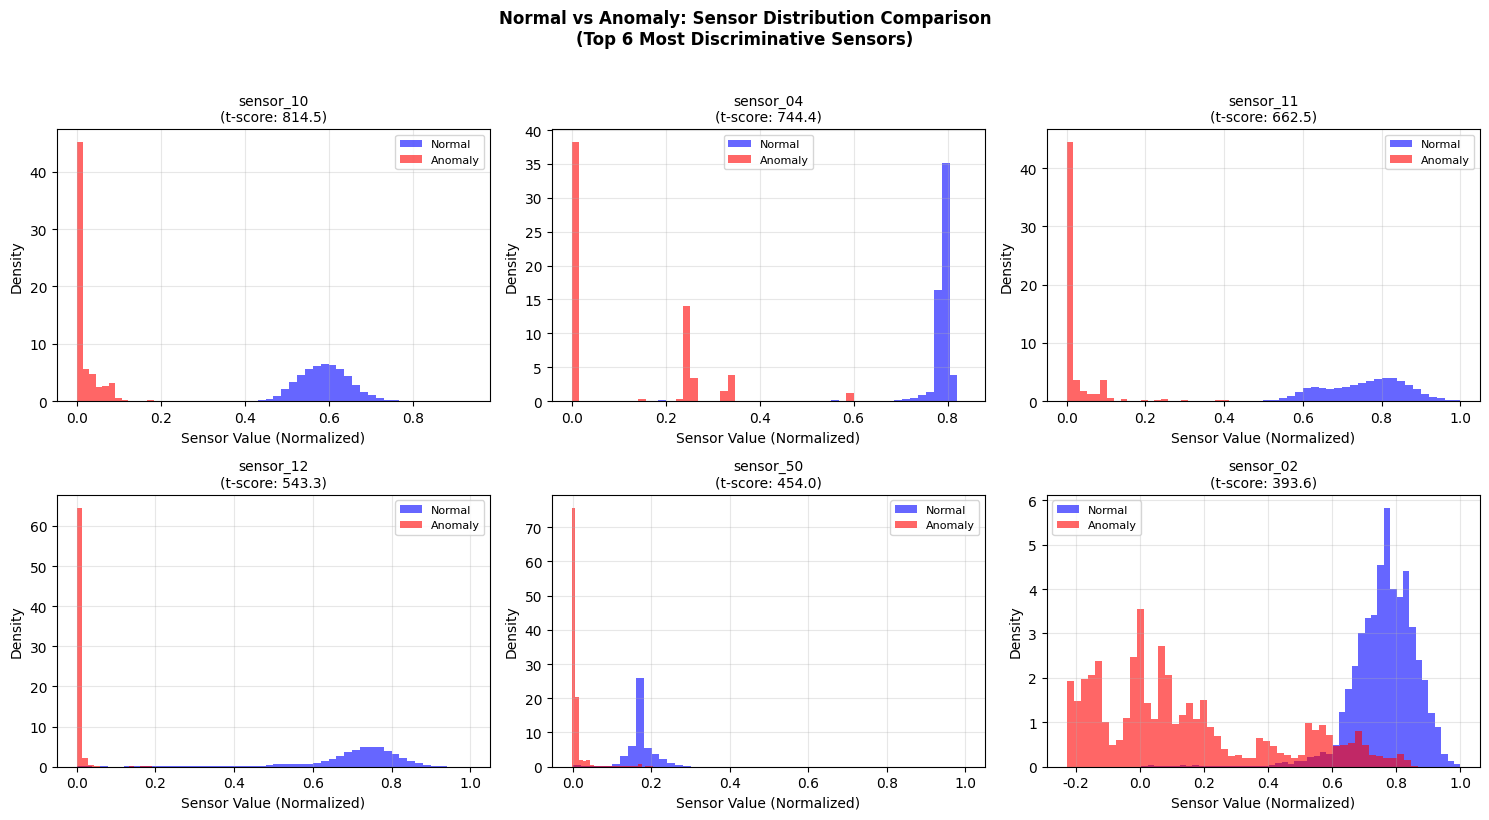

In [13]:
# ============================================================
# 시각화 1: 정상/이상 센서 값 분포 비교
# ============================================================

def plot_sensor_distribution(X_test_scaled, y_test, sensor_cols, n_sensors=6):
    """
    정상 vs 이상 데이터의 센서 값 분포를 비교하는 히스토그램
    
    Parameters:
    -----------
    X_test_scaled : 테스트 데이터 (정규화됨)
    y_test : 테스트 라벨 (0: 정상, 1: 이상)
    sensor_cols : 센서 컬럼명 리스트
    n_sensors : 표시할 센서 수
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    # 정상/이상 데이터 분리
    normal_data = X_test_scaled[y_test == 0]
    anomaly_data = X_test_scaled[y_test == 1]
    
    # 분포 차이가 큰 센서를 선택 (t-test 기반)
    from scipy import stats
    t_scores = []
    for i in range(X_test_scaled.shape[1]):
        t_stat, _ = stats.ttest_ind(normal_data[:, i], anomaly_data[:, i])
        t_scores.append(abs(t_stat))
    
    # 가장 차이가 큰 센서 인덱스
    top_sensors = np.argsort(t_scores)[-n_sensors:][::-1]
    
    for idx, sensor_idx in enumerate(top_sensors):
        ax = axes[idx]
        sensor_name = sensor_cols[sensor_idx] if sensor_idx < len(sensor_cols) else f'sensor_{sensor_idx}'
        
        # 히스토그램
        ax.hist(normal_data[:, sensor_idx], bins=50, alpha=0.6, 
                label='Normal', color='blue', density=True)
        ax.hist(anomaly_data[:, sensor_idx], bins=50, alpha=0.6, 
                label='Anomaly', color='red', density=True)
        
        ax.set_xlabel('Sensor Value (Normalized)')
        ax.set_ylabel('Density')
        ax.set_title(f'{sensor_name}\n(t-score: {t_scores[sensor_idx]:.1f})', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Normal vs Anomaly: Sensor Distribution Comparison\n(Top 6 Most Discriminative Sensors)', 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('01_sensor_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return top_sensors

# 시각화 실행
top_sensors = plot_sensor_distribution(X_test_scaled, y_test, sensor_cols)

### 시각화 해석 가이드

위 히스토그램에서 확인해야 할 점:

1. **분포 분리**: 파란색(정상)과 빨간색(이상) 분포가 얼마나 분리되어 있는가?
   - 분리가 클수록 해당 센서가 이상 탐지에 유용함
   
2. **t-score**: 두 그룹 간 평균 차이를 표준화한 값
   - t-score가 클수록 정상과 이상의 차이가 명확함
   
3. **이상 데이터 특성**: 이상 데이터가 정상 범위를 벗어나는 방향 확인
   - 값이 높아지는지, 낮아지는지, 또는 분산이 커지는지

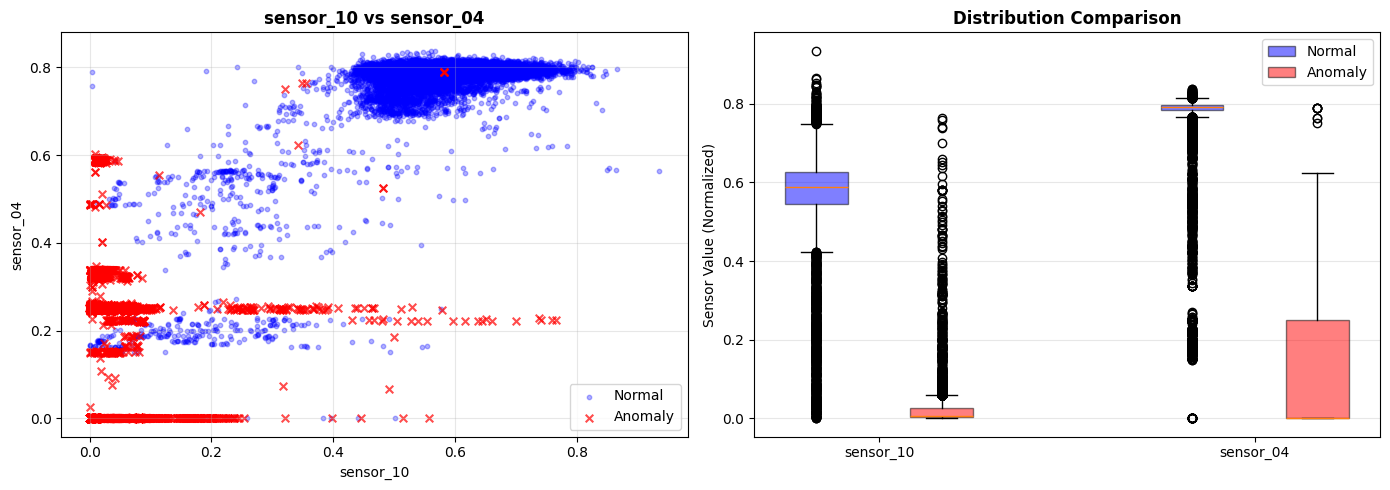

In [14]:
# ============================================================
# 시각화 2: 센서 간 상관관계 (정상 vs 이상)
# ============================================================

def plot_sensor_scatter(X_test_scaled, y_test, sensor_cols, sensor_idx_1, sensor_idx_2):
    """
    두 센서 간의 관계를 산점도로 시각화
    정상/이상 데이터가 어떻게 다르게 분포하는지 확인
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    normal_data = X_test_scaled[y_test == 0]
    anomaly_data = X_test_scaled[y_test == 1]
    
    # 센서 이름
    name1 = sensor_cols[sensor_idx_1] if sensor_idx_1 < len(sensor_cols) else f'sensor_{sensor_idx_1}'
    name2 = sensor_cols[sensor_idx_2] if sensor_idx_2 < len(sensor_cols) else f'sensor_{sensor_idx_2}'
    
    # 1. 전체 데이터 산점도
    ax = axes[0]
    ax.scatter(normal_data[:, sensor_idx_1], normal_data[:, sensor_idx_2],
               alpha=0.3, c='blue', s=10, label='Normal')
    ax.scatter(anomaly_data[:, sensor_idx_1], anomaly_data[:, sensor_idx_2],
               alpha=0.7, c='red', s=30, marker='x', label='Anomaly')
    ax.set_xlabel(name1)
    ax.set_ylabel(name2)
    ax.set_title(f'{name1} vs {name2}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. 센서별 박스플롯
    ax = axes[1]
    positions = [1, 2, 4, 5]
    bp = ax.boxplot([normal_data[:, sensor_idx_1], anomaly_data[:, sensor_idx_1],
                     normal_data[:, sensor_idx_2], anomaly_data[:, sensor_idx_2]],
                    positions=positions, patch_artist=True)
    
    colors = ['blue', 'red', 'blue', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    
    ax.set_xticks([1.5, 4.5])
    ax.set_xticklabels([name1, name2])
    ax.set_ylabel('Sensor Value (Normalized)')
    ax.set_title('Distribution Comparison', fontweight='bold')
    ax.legend([bp['boxes'][0], bp['boxes'][1]], ['Normal', 'Anomaly'], loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('02_sensor_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

# 가장 판별력 있는 두 센서로 시각화
if len(top_sensors) >= 2:
    plot_sensor_scatter(X_test_scaled, y_test, sensor_cols, top_sensors[0], top_sensors[1])

## 2.6 오토인코더 모델 구현

Keras의 Sequential API를 사용하여 오토인코더를 구현함. 구조는 다음과 같음:

```
입력층 (51) → 은닉층 (32) → 은닉층 (16) → *잠재층 (8)* → 은닉층 (16) → 은닉층 (32) → 출력층 (51)
```

### 설계 시 고려사항

1. **잠재 차원**: 입력 차원의 15~30% 정도로 설정 (51차원 → 8차원)
2. **점진적 압축**: 한 번에 크게 줄이지 않고 단계적으로
3. **BatchNormalization**: 학습 안정화
4. **Dropout**: 과적합 방지
5. **출력 활성화**: sigmoid (0~1 범위 출력)

In [15]:
# ============================================================
# 오토인코더 모델 정의
# ============================================================

def build_autoencoder(input_dim, latent_dim=8):
    """
    Sequential API로 오토인코더 생성
    
    Parameters:
    -----------
    input_dim : 입력 차원 (센서 수)
    latent_dim : 잠재 공간 차원 (병목)
    
    Returns:
    --------
    model : 오토인코더 모델
    
    Architecture:
    -------------
    인코더: input_dim → 32 → 16 → latent_dim
    디코더: latent_dim → 16 → 32 → input_dim
    """
    model = Sequential([
        # ========== 인코더 (Encoder) ==========
        # 첫 번째 은닉층: 입력 압축 시작
        Dense(32, activation='relu', input_shape=(input_dim,), name='encoder_1'),
        BatchNormalization(),
        Dropout(0.2),
        
        # 두 번째 은닉층: 추가 압축
        Dense(16, activation='relu', name='encoder_2'),
        BatchNormalization(),
        
        # 잠재층 (Latent Layer): 가장 압축된 표현
        Dense(latent_dim, activation='relu', name='latent'),
        
        # ========== 디코더 (Decoder) ==========
        # 복원 시작
        Dense(16, activation='relu', name='decoder_1'),
        BatchNormalization(),
        
        # 추가 복원
        Dense(32, activation='relu', name='decoder_2'),
        BatchNormalization(),
        Dropout(0.2),
        
        # 출력층: 원본과 동일한 차원으로 복원
        # sigmoid: 출력을 0~1 범위로 제한 (MinMaxScaler와 일관성)
        Dense(input_dim, activation='sigmoid', name='output')
    ], name='autoencoder')
    
    return model

# 모델 생성
input_dim = X_train_scaled.shape[1]  # 센서 수
latent_dim = 8  # 잠재 차원 (입력의 약 15%)

autoencoder = build_autoencoder(input_dim, latent_dim)

print("=" * 70)
print("오토인코더 모델 구조")
print("=" * 70)
autoencoder.summary()

오토인코더 모델 구조


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_1 (Dense)                    │ (None, 32)                  │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_2 (Dense)                    │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_1 (Dense)                    │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_2 (Dense)                    │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 51)                  │           1,683 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,083 (19.86 KB)

 Trainable params: 4,891 (19.11 KB)

 Non-trainable params: 192 (768.00 B)

### 모델 구조 해석

위 summary에서 확인할 수 있는 정보:

1. **Layer 이름**: encoder_1, encoder_2, latent, decoder_1, decoder_2, output
2. **Output Shape**: 각 층의 출력 차원
3. **Param #**: 학습되는 파라미터 수

### 파라미터 수 계산 예시

첫 번째 Dense 층 (encoder_1)의 파라미터 수:

$$\text{Param} = (\text{입력 차원} \times \text{출력 노드}) + \text{출력 노드}$$
$$= (51 \times 32) + 32 = 1,632 + 32 = 1,664$$

여기서 $51 \times 32$는 가중치(W), $32$는 편향(b)임.

In [16]:
# ============================================================
# 모델 컴파일
# ============================================================

# 옵티마이저: Adam (적응형 학습률)
# 손실 함수: MSE (평균 제곱 오차)
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

print("\n모델 컴파일 완료")
print("  - Optimizer: Adam (learning_rate=0.001)")
print("  - Loss Function: MSE (Mean Squared Error)")
print("\n[참고] 왜 MSE를 사용하는가?")
print("  - MSE는 원본과 재구성 결과의 차이를 제곱하여 평균")
print("  - 큰 오차에 더 큰 페널티를 부여하여 복원 품질 향상")
print("  - 미분 가능하여 경사하강법 적용 가능")


모델 컴파일 완료
  - Optimizer: Adam (learning_rate=0.001)
  - Loss Function: MSE (Mean Squared Error)

[참고] 왜 MSE를 사용하는가?
  - MSE는 원본과 재구성 결과의 차이를 제곱하여 평균
  - 큰 오차에 더 큰 페널티를 부여하여 복원 품질 향상
  - 미분 가능하여 경사하강법 적용 가능


In [19]:
# ============================================================
# 모델 학습
# ============================================================

print("\n" + "=" * 70)
print("모델 학습 시작")
print("=" * 70)

# Early Stopping 콜백
# 검증 손실이 15 에포크 동안 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,  # 최적 가중치 복원
    verbose=1
)

# 핵심: 입력 = 타겟 (X, X)
# 오토인코더는 입력을 그대로 출력으로 재구성하도록 학습
print("\n[핵심] model.fit(X, X): 입력과 타겟이 동일")
print("  - 오토인코더는 입력을 그대로 복원하는 것이 목표")
print("  - 정상 데이터만 학습하여 정상 패턴을 기억")

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,  # 입력 = 타겟
    epochs=30,
    batch_size=64,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n학습 완료!")
print(f"  - 실제 학습 에포크: {len(history.history['loss'])}")
print(f"  - 최종 학습 손실: {history.history['loss'][-1]:.6f}")
print(f"  - 최종 검증 손실: {history.history['val_loss'][-1]:.6f}")


모델 학습 시작

[핵심] model.fit(X, X): 입력과 타겟이 동일
  - 오토인코더는 입력을 그대로 복원하는 것이 목표
  - 정상 데이터만 학습하여 정상 패턴을 기억
Epoch 1/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 2/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0028 - val_loss: 0.0019
Epoch 3/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 4/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0028 - val_loss: 0.0019
Epoch 5/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 6/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 7/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 8/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 9/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 10/30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 11/30
2573/2

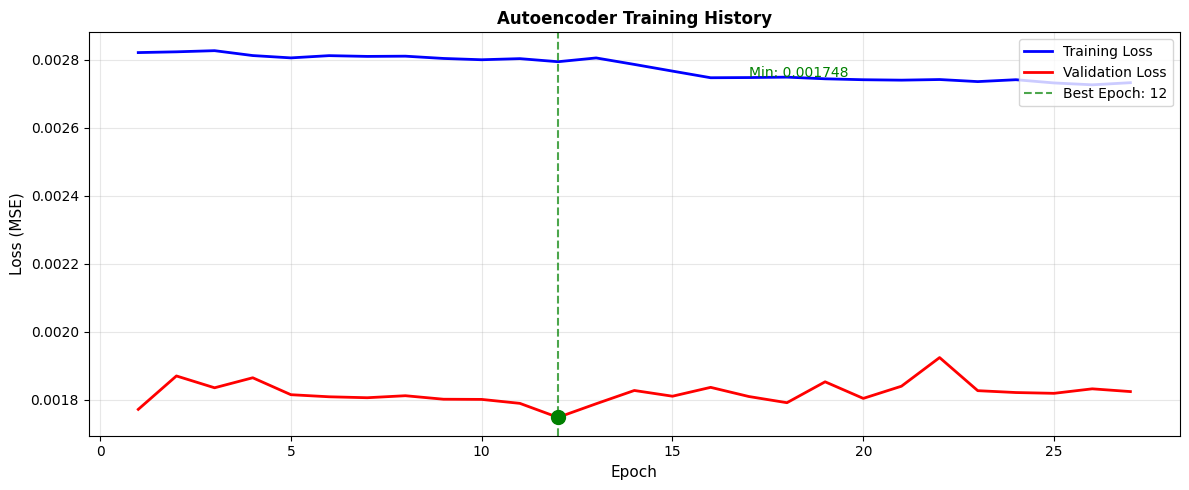

In [20]:
# ============================================================
# 학습 곡선 시각화
# ============================================================

def plot_training_history(history):
    """
    학습 곡선 시각화
    - 학습 손실과 검증 손실의 변화 추이
    - 과적합 여부 확인
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # 손실 곡선
    ax.plot(epochs, history.history['loss'], 'b-', 
            label='Training Loss', linewidth=2)
    ax.plot(epochs, history.history['val_loss'], 'r-', 
            label='Validation Loss', linewidth=2)
    
    # 최적점 표시
    min_val_loss = min(history.history['val_loss'])
    min_epoch = history.history['val_loss'].index(min_val_loss) + 1
    ax.axvline(min_epoch, color='green', linestyle='--', alpha=0.7, 
               label=f'Best Epoch: {min_epoch}')
    ax.scatter(min_epoch, min_val_loss, color='green', s=100, zorder=5)
    ax.annotate(f'Min: {min_val_loss:.6f}', 
                xy=(min_epoch, min_val_loss),
                xytext=(min_epoch + 5, min_val_loss + 0.001),
                fontsize=10, color='green')
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss (MSE)', fontsize=11)
    ax.set_title('Autoencoder Training History', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('03_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

### 학습 곡선 해석

1. **정상 학습**: 학습 손실과 검증 손실이 함께 감소하면 정상적으로 학습되고 있음
2. **과적합 징후**: 학습 손실은 감소하는데 검증 손실이 증가하면 과적합
3. **수렴**: 두 곡선이 평평해지면 학습이 수렴한 것
4. **Early Stopping**: 검증 손실이 더 이상 개선되지 않으면 자동으로 학습 중단

---

# 3: 이상 탐지 및 평가

---

## 3.1 재구성 오차 계산

학습된 오토인코더를 사용하여 테스트 데이터의 재구성 오차를 계산함. 재구성 오차가 높은 샘플은 이상으로 판정됨.

In [21]:
# ============================================================
# 재구성 오차 계산
# ============================================================

def calculate_reconstruction_error(model, X):
    """
    재구성 오차 계산
    
    Parameters:
    -----------
    model : 학습된 오토인코더
    X : 입력 데이터 (정규화된 상태)
    
    Returns:
    --------
    reconstruction_error : 샘플별 재구성 오차 (MSE)
    X_reconstructed : 재구성된 데이터
    
    수식:
    -----
    MSE_i = (1/d) * sum((x_i - x_hat_i)^2)
    여기서 d는 특성 수, i는 샘플 인덱스
    """
    # 재구성
    X_reconstructed = model.predict(X, verbose=0)
    
    # 샘플별 MSE 계산
    # axis=1: 각 샘플에 대해 모든 특성의 오차를 평균
    reconstruction_error = np.mean((X - X_reconstructed) ** 2, axis=1)
    
    return reconstruction_error, X_reconstructed

# 재구성 오차 계산
reconstruction_error, X_reconstructed = calculate_reconstruction_error(
    autoencoder, X_test_scaled
)

print("=" * 70)
print("재구성 오차 통계")
print("=" * 70)

# 정상/이상 데이터 분리
normal_error = reconstruction_error[y_test == 0]
anomaly_error = reconstruction_error[y_test == 1]

print(f"\n[전체 데이터]")
print(f"  - 평균 오차: {reconstruction_error.mean():.6f}")
print(f"  - 표준편차: {reconstruction_error.std():.6f}")
print(f"  - 범위: [{reconstruction_error.min():.6f}, {reconstruction_error.max():.6f}]")

print(f"\n[정상 데이터] (n={len(normal_error):,})")
print(f"  - 평균 오차 (mu): {normal_error.mean():.6f}")
print(f"  - 표준편차 (sigma): {normal_error.std():.6f}")
print(f"  - 범위: [{normal_error.min():.6f}, {normal_error.max():.6f}]")

print(f"\n[이상 데이터] (n={len(anomaly_error):,})")
print(f"  - 평균 오차: {anomaly_error.mean():.6f}")
print(f"  - 표준편차: {anomaly_error.std():.6f}")
print(f"  - 범위: [{anomaly_error.min():.6f}, {anomaly_error.max():.6f}]")

print(f"\n[분리도] 이상/정상 평균 비율: {anomaly_error.mean() / normal_error.mean():.2f}배")

재구성 오차 통계

[전체 데이터]
  - 평균 오차: 0.009952
  - 표준편차: 0.016234
  - 범위: [0.000218, 0.203855]

[정상 데이터] (n=41,168)
  - 평균 오차 (mu): 0.001748
  - 표준편차 (sigma): 0.002283
  - 범위: [0.000218, 0.070602]

[이상 데이터] (n=14,484)
  - 평균 오차: 0.033269
  - 표준편차: 0.016212
  - 범위: [0.000414, 0.203855]

[분리도] 이상/정상 평균 비율: 19.04배


### 해석

재구성 오차 통계에서 확인해야 할 점:

1. **정상 데이터의 평균 오차**가 **이상 데이터의 평균 오차**보다 작아야 함
2. 이상/정상 평균 비율이 클수록 분리가 잘 되어 탐지가 용이함
3. 두 그룹의 범위가 겹치는 정도가 적을수록 좋음

---

## 3.2 임계값 설정 및 이상 판정

In [22]:
# ============================================================
# 임계값 설정 및 성능 비교
# ============================================================

def evaluate_thresholds(reconstruction_error, y_test, k_values=[2.0, 2.5, 3.0]):
    """
    다양한 k 값에 대한 임계값 계산 및 성능 비교
    
    임계값 공식: theta = mu + k * sigma
    - mu: 정상 데이터 재구성 오차의 평균
    - sigma: 정상 데이터 재구성 오차의 표준편차
    - k: 민감도 조절 파라미터
    """
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    # 정상 데이터의 통계량 (학습 데이터 기준으로 계산해야 하지만, 
    # 여기서는 테스트 데이터의 정상 부분으로 대체)
    normal_error = reconstruction_error[y_test == 0]
    mu = np.mean(normal_error)
    sigma = np.std(normal_error)
    
    print("=" * 70)
    print("임계값 설정 및 성능 평가")
    print("=" * 70)
    print(f"\n[기준값]")
    print(f"  - 평균 (mu): {mu:.6f}")
    print(f"  - 표준편차 (sigma): {sigma:.6f}")
    
    results = []
    
    print("\n" + "-" * 70)
    print(f"{'k 값':^8} | {'임계값':^12} | {'Precision':^10} | {'Recall':^10} | {'F1-Score':^10} | {'탐지 수':^8}")
    print("-" * 70)
    
    for k in k_values:
        # 임계값 계산: theta = mu + k * sigma
        threshold = mu + k * sigma
        
        # 이상 판정: 재구성 오차 > 임계값이면 이상(1)
        y_pred = (reconstruction_error > threshold).astype(int)
        
        # 성능 지표 계산
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        n_detected = y_pred.sum()
        
        results.append({
            'k': k,
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'n_detected': n_detected
        })
        
        print(f"{k:^8.1f} | {threshold:^12.6f} | {precision:^10.4f} | {recall:^10.4f} | {f1:^10.4f} | {n_detected:^8}")
    
    print("-" * 70)
    
    return results, mu, sigma

# 다양한 k 값으로 평가
results, mu, sigma = evaluate_thresholds(reconstruction_error, y_test, 
                                          k_values=[1.5, 2.0, 2.5, 3.0, 3.5])

임계값 설정 및 성능 평가

[기준값]
  - 평균 (mu): 0.001748
  - 표준편차 (sigma): 0.002283

----------------------------------------------------------------------
  k 값    |     임계값      | Precision  |   Recall   |  F1-Score  |   탐지 수  
----------------------------------------------------------------------
  1.5    |   0.005172   |   0.8718   |   0.9673   |   0.9170   |  16071  
  2.0    |   0.006313   |   0.9108   |   0.9435   |   0.9269   |  15005  
  2.5    |   0.007455   |   0.9325   |   0.9209   |   0.9267   |  14303  
  3.0    |   0.008596   |   0.9493   |   0.9040   |   0.9261   |  13792  
  3.5    |   0.009738   |   0.9603   |   0.8943   |   0.9261   |  13489  
----------------------------------------------------------------------


### 성능 지표 해석

| 지표 | 의미 | 계산식 |
|:---:|:---|:---|
| **Precision** | 이상으로 예측한 것 중 실제 이상의 비율 | TP / (TP + FP) |
| **Recall** | 실제 이상 중 이상으로 예측한 비율 | TP / (TP + FN) |
| **F1-Score** | Precision과 Recall의 조화 평균 | 2 * (P * R) / (P + R) |

### k 값 선택 기준

- **k가 작을 때** (예: k=1.5): 민감한 탐지 → Recall 높음, Precision 낮음 (오탐 많음)
- **k가 클 때** (예: k=3.5): 보수적 탐지 → Precision 높음, Recall 낮음 (미탐 많음)
- **F1-Score가 가장 높은 k**: 균형 잡힌 성능

In [23]:
# ============================================================
# 최적 임계값 선택 (F1-Score 기준)
# ============================================================

best_result = max(results, key=lambda x: x['f1'])
best_k = best_result['k']
threshold = best_result['threshold']

print(f"\n[최적 파라미터] (F1-Score 기준)")
print(f"  - 최적 k 값: {best_k}")
print(f"  - 최적 임계값: {threshold:.6f}")
print(f"  - F1-Score: {best_result['f1']:.4f}")

# 최종 예측
y_pred = (reconstruction_error > threshold).astype(int)


[최적 파라미터] (F1-Score 기준)
  - 최적 k 값: 2.0
  - 최적 임계값: 0.006313
  - F1-Score: 0.9269


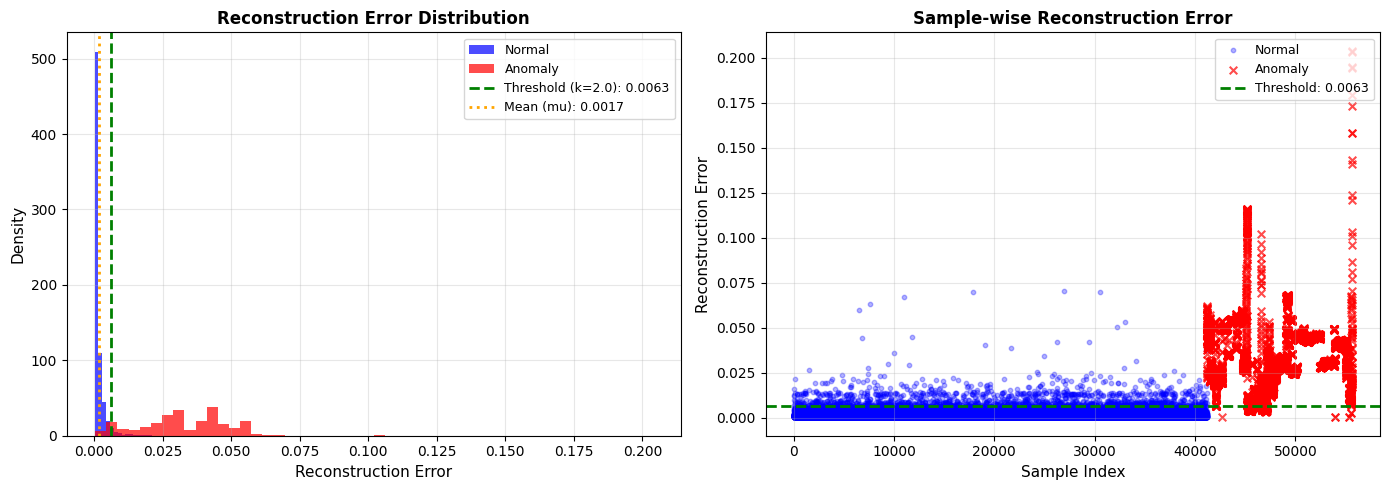

In [24]:
# ============================================================
# 재구성 오차 분포 시각화
# ============================================================

def plot_error_distribution(reconstruction_error, y_test, mu, sigma, k):
    """
    재구성 오차 분포 시각화
    - 정상/이상 데이터의 분포
    - 임계값 표시
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    normal_error = reconstruction_error[y_test == 0]
    anomaly_error = reconstruction_error[y_test == 1]
    threshold = mu + k * sigma
    
    # 1. 히스토그램
    ax = axes[0]
    ax.hist(normal_error, bins=50, alpha=0.7, label='Normal', 
            color='blue', density=True)
    ax.hist(anomaly_error, bins=50, alpha=0.7, label='Anomaly', 
            color='red', density=True)
    
    # 임계값 및 평균 표시
    ax.axvline(threshold, color='green', linestyle='--', linewidth=2,
               label=f'Threshold (k={k}): {threshold:.4f}')
    ax.axvline(mu, color='orange', linestyle=':', linewidth=2,
               label=f'Mean (mu): {mu:.4f}')
    
    ax.set_xlabel('Reconstruction Error', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('Reconstruction Error Distribution', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 2. 샘플별 오차 (산점도)
    ax = axes[1]
    normal_idx = np.where(y_test == 0)[0]
    anomaly_idx = np.where(y_test == 1)[0]
    
    ax.scatter(normal_idx, reconstruction_error[y_test == 0],
               alpha=0.3, c='blue', s=10, label='Normal')
    ax.scatter(anomaly_idx, reconstruction_error[y_test == 1],
               alpha=0.7, c='red', s=30, marker='x', label='Anomaly')
    
    ax.axhline(threshold, color='green', linestyle='--', linewidth=2,
               label=f'Threshold: {threshold:.4f}')
    
    ax.set_xlabel('Sample Index', fontsize=11)
    ax.set_ylabel('Reconstruction Error', fontsize=11)
    ax.set_title('Sample-wise Reconstruction Error', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('04_error_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_error_distribution(reconstruction_error, y_test, mu, sigma, best_k)

### 시각화 해석

**좌측 히스토그램**:
- 파란색(정상)과 빨간색(이상) 분포가 분리되어 있는지 확인
- 녹색 임계값이 두 분포를 잘 분리하는지 확인
- 분포가 겹치는 영역이 오분류가 발생하는 곳

**우측 산점도**:
- 임계값 위쪽의 점들이 이상으로 판정됨
- 빨간 점(실제 이상)이 임계값 위에 많을수록 좋음 (높은 Recall)
- 파란 점(실제 정상)이 임계값 아래에 많을수록 좋음 (낮은 오탐률)

---

## 3.3 최종 성능 평가

In [25]:
# ============================================================
# 최종 성능 평가: 분류 보고서
# ============================================================

print("=" * 70)
print("최종 성능 평가")
print("=" * 70)

print("\n[분류 보고서]")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# 혼동 행렬
print("\n[혼동 행렬 (Confusion Matrix)]")
cm = confusion_matrix(y_test, y_pred)
print(f"                 예측: Normal    예측: Anomaly")
print(f"실제: Normal     {cm[0,0]:>10}    {cm[0,1]:>10}")
print(f"실제: Anomaly    {cm[1,0]:>10}    {cm[1,1]:>10}")

# 혼동 행렬 해석
print("\n[혼동 행렬 해석]")
print(f"  - True Negative (TN): {cm[0,0]:,} - 정상을 정상으로 올바르게 판정")
print(f"  - False Positive (FP): {cm[0,1]:,} - 정상을 이상으로 잘못 판정 (오탐)")
print(f"  - False Negative (FN): {cm[1,0]:,} - 이상을 정상으로 잘못 판정 (미탐)")
print(f"  - True Positive (TP): {cm[1,1]:,} - 이상을 이상으로 올바르게 판정")

# AUC-ROC Score
auc_score = roc_auc_score(y_test, reconstruction_error)
print(f"\n[AUC-ROC Score]: {auc_score:.4f}")
print("  - 0.5: 무작위 분류기 수준")
print("  - 0.7~0.8: 수용 가능")
print("  - 0.8~0.9: 우수")
print("  - 0.9 이상: 탁월")

최종 성능 평가

[분류 보고서]
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97     41168
     Anomaly       0.91      0.94      0.93     14484

    accuracy                           0.96     55652
   macro avg       0.95      0.96      0.95     55652
weighted avg       0.96      0.96      0.96     55652


[혼동 행렬 (Confusion Matrix)]
                 예측: Normal    예측: Anomaly
실제: Normal          39829          1339
실제: Anomaly           818         13666

[혼동 행렬 해석]
  - True Negative (TN): 39,829 - 정상을 정상으로 올바르게 판정
  - False Positive (FP): 1,339 - 정상을 이상으로 잘못 판정 (오탐)
  - False Negative (FN): 818 - 이상을 정상으로 잘못 판정 (미탐)
  - True Positive (TP): 13,666 - 이상을 이상으로 올바르게 판정

[AUC-ROC Score]: 0.9945
  - 0.5: 무작위 분류기 수준
  - 0.7~0.8: 수용 가능
  - 0.8~0.9: 우수
  - 0.9 이상: 탁월


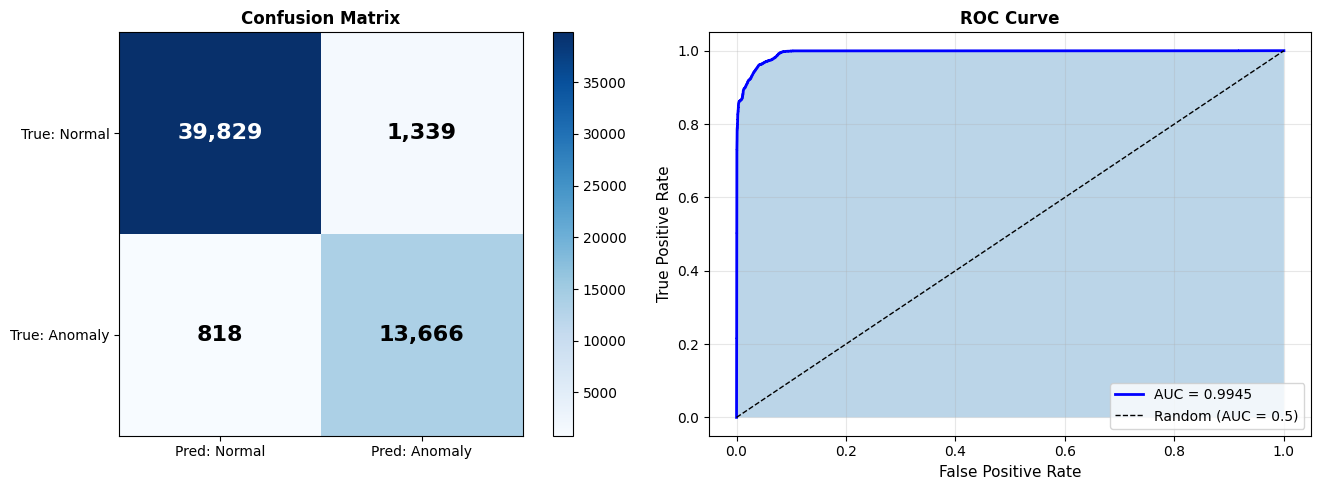

In [26]:
# ============================================================
# ROC 곡선 및 혼동 행렬 시각화
# ============================================================

def plot_evaluation_results(y_test, y_pred, reconstruction_error):
    """
    평가 결과 시각화
    - 혼동 행렬 히트맵
    - ROC 곡선
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. 혼동 행렬 히트맵
    ax = axes[0]
    cm = confusion_matrix(y_test, y_pred)
    
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Normal', 'Pred: Anomaly'], fontsize=10)
    ax.set_yticklabels(['True: Normal', 'True: Anomaly'], fontsize=10)
    
    # 값 표시
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                   fontsize=16, fontweight='bold', color=color)
    
    ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)
    
    # 2. ROC 곡선
    ax = axes[1]
    fpr, tpr, thresholds = roc_curve(y_test, reconstruction_error)
    auc = roc_auc_score(y_test, reconstruction_error)
    
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
    ax.fill_between(fpr, tpr, alpha=0.3)
    
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('05_evaluation_results.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_evaluation_results(y_test, y_pred, reconstruction_error)

### ROC 곡선 해석

ROC(Receiver Operating Characteristic) 곡선은 **임계값 변화에 따른 TPR과 FPR의 관계**를 보여줌:

- **TPR (True Positive Rate)** = Recall = 실제 이상 중 탐지한 비율
- **FPR (False Positive Rate)** = 실제 정상 중 오탐한 비율

**해석 기준**:
- 곡선이 **좌상단**에 가까울수록 좋은 성능 (높은 TPR, 낮은 FPR)
- **AUC (Area Under Curve)** 가 클수록 좋음 (최대 1.0)
- 대각선은 무작위 분류기 (AUC = 0.5)

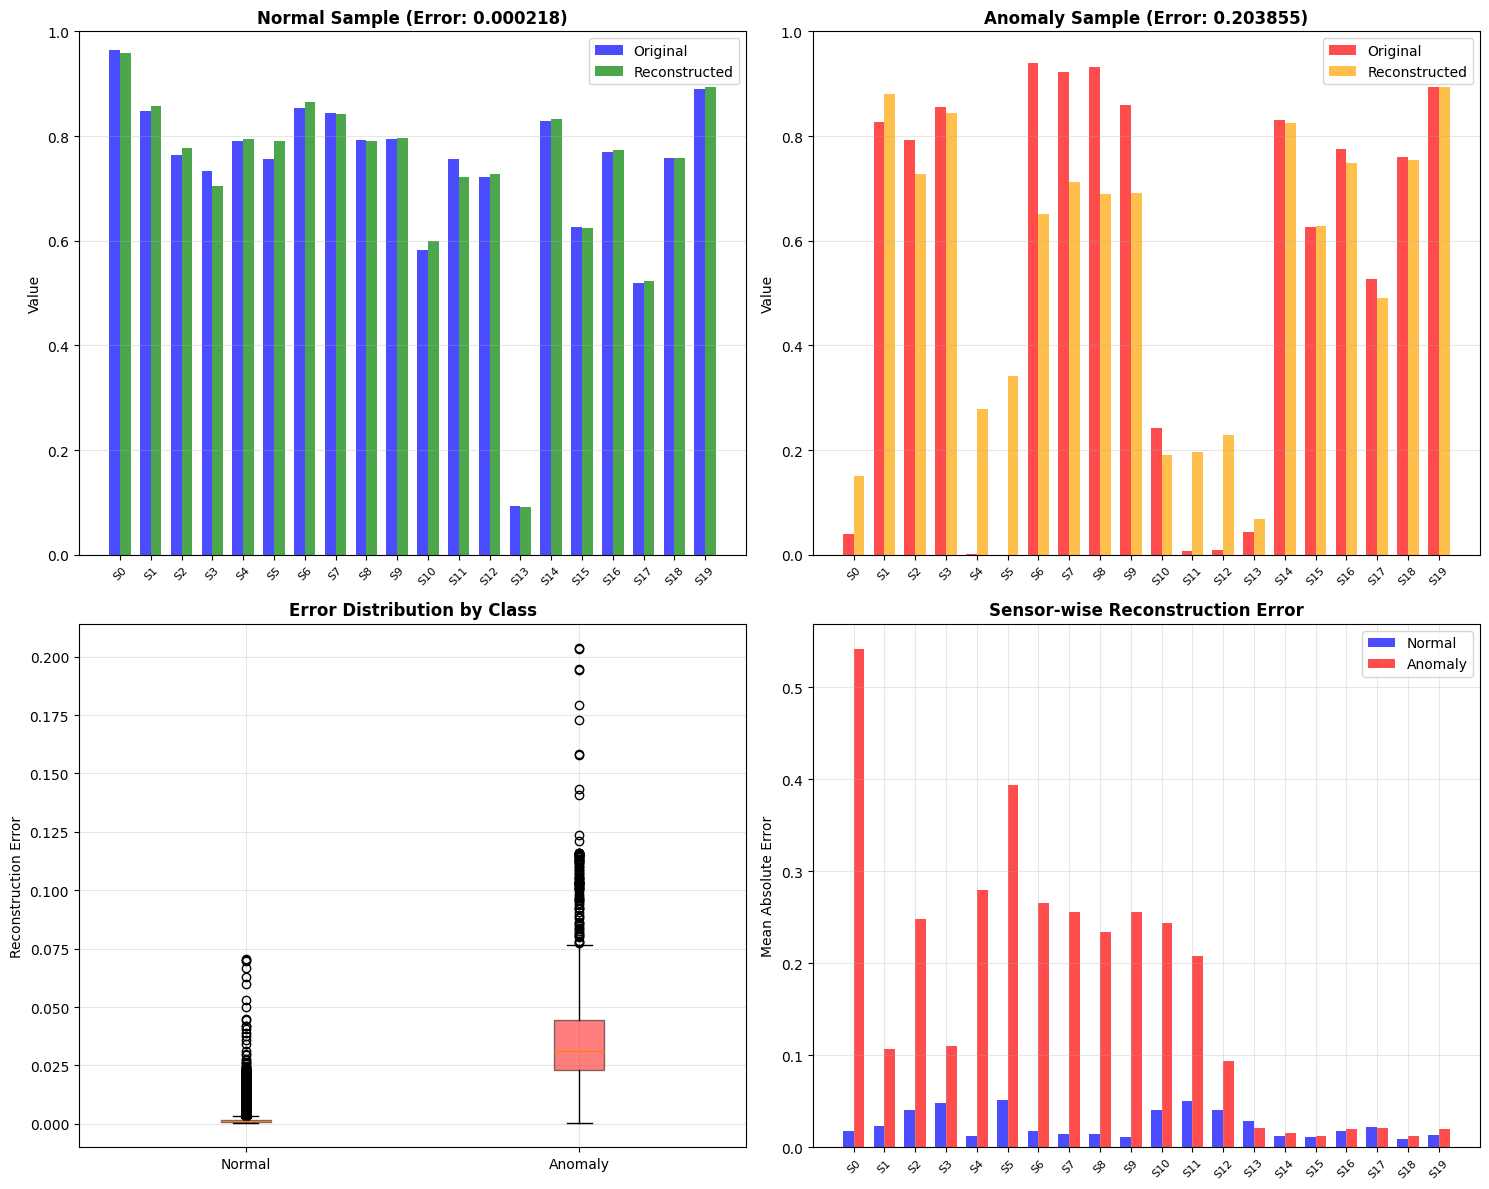

In [27]:
# ============================================================
# 재구성 결과 비교 시각화
# ============================================================

def plot_reconstruction_comparison(X_test_scaled, X_reconstructed, y_test, 
                                    reconstruction_error, sensor_cols):
    """
    정상/이상 샘플의 재구성 결과 비교
    - 원본과 재구성된 값의 차이
    - 센서별 기여도
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 정상 샘플 (오차가 가장 작은 것)
    normal_idx = np.where(y_test == 0)[0]
    best_normal_idx = normal_idx[np.argmin(reconstruction_error[normal_idx])]
    
    # 이상 샘플 (오차가 가장 큰 것)
    anomaly_idx = np.where(y_test == 1)[0]
    worst_anomaly_idx = anomaly_idx[np.argmax(reconstruction_error[anomaly_idx])]
    
    # 센서 수 제한 (시각화용)
    n_display = min(20, len(sensor_cols))
    x = np.arange(n_display)
    width = 0.35
    
    # 1. 정상 샘플 재구성
    ax = axes[0, 0]
    ax.bar(x - width/2, X_test_scaled[best_normal_idx, :n_display], width,
           label='Original', alpha=0.7, color='blue')
    ax.bar(x + width/2, X_reconstructed[best_normal_idx, :n_display], width,
           label='Reconstructed', alpha=0.7, color='green')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{i}' for i in range(n_display)], rotation=45, fontsize=8)
    ax.set_ylabel('Value')
    ax.set_title(f'Normal Sample (Error: {reconstruction_error[best_normal_idx]:.6f})',
                fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. 이상 샘플 재구성
    ax = axes[0, 1]
    ax.bar(x - width/2, X_test_scaled[worst_anomaly_idx, :n_display], width,
           label='Original', alpha=0.7, color='red')
    ax.bar(x + width/2, X_reconstructed[worst_anomaly_idx, :n_display], width,
           label='Reconstructed', alpha=0.7, color='orange')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{i}' for i in range(n_display)], rotation=45, fontsize=8)
    ax.set_ylabel('Value')
    ax.set_title(f'Anomaly Sample (Error: {reconstruction_error[worst_anomaly_idx]:.6f})',
                fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. 정상 vs 이상 재구성 오차 박스플롯
    ax = axes[1, 0]
    normal_errors = reconstruction_error[y_test == 0]
    anomaly_errors = reconstruction_error[y_test == 1]
    
    bp = ax.boxplot([normal_errors, anomaly_errors],
                    labels=['Normal', 'Anomaly'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.5)
    
    ax.set_ylabel('Reconstruction Error')
    ax.set_title('Error Distribution by Class', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 4. 센서별 평균 재구성 오차
    ax = axes[1, 1]
    sensor_errors = np.abs(X_test_scaled - X_reconstructed)
    
    normal_sensor_error = sensor_errors[y_test == 0].mean(axis=0)[:n_display]
    anomaly_sensor_error = sensor_errors[y_test == 1].mean(axis=0)[:n_display]
    
    ax.bar(x - width/2, normal_sensor_error, width,
           label='Normal', alpha=0.7, color='blue')
    ax.bar(x + width/2, anomaly_sensor_error, width,
           label='Anomaly', alpha=0.7, color='red')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{i}' for i in range(n_display)], rotation=45, fontsize=8)
    ax.set_ylabel('Mean Absolute Error')
    ax.set_title('Sensor-wise Reconstruction Error', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('06_reconstruction_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_reconstruction_comparison(X_test_scaled, X_reconstructed, y_test,
                               reconstruction_error, sensor_cols)

### 재구성 결과 해석

**상단 막대 그래프**:
- 정상 샘플: Original(파랑)과 Reconstructed(초록)가 거의 일치 → 재구성 성공
- 이상 샘플: Original(빨강)과 Reconstructed(주황)가 불일치 → 재구성 실패

**하단 좌측 박스플롯**:
- 정상 데이터는 재구성 오차가 낮고 분산이 작음
- 이상 데이터는 재구성 오차가 높고 분산이 큼

**하단 우측 센서별 오차**:
- 어떤 센서에서 이상 시 재구성 오차가 크게 증가하는지 파악
- 이상 탐지에 기여도가 높은 센서 식별

# 차시 요약

## 오토인코더 수식 요약

| 구성요소 | 수식 | 설명 |
|:---:|:---:|:---|
| 인코더 | $\mathbf{z} = \sigma(\mathbf{W}_e \mathbf{x} + \mathbf{b}_e)$ | 입력을 잠재 공간으로 압축 |
| 디코더 | $\hat{\mathbf{x}} = \sigma(\mathbf{W}_d \mathbf{z} + \mathbf{b}_d)$ | 잠재 공간에서 복원 |
| 재구성 오차 | $L = \frac{1}{n}\sum\|\mathbf{x} - \hat{\mathbf{x}}\|^2$ | MSE로 계산 |
| 임계값 | $\theta = \mu + k \cdot \sigma$ | 정상 데이터 기준 설정 |
| 판정 | $L > \theta \Rightarrow$ 이상 | 임계값 초과 시 이상 |

## 핵심 코드 요약

```python
# 1. 오토인코더 구성
autoencoder = Sequential([
    Dense(32, activation='relu', input_shape=(input_dim,)),  # 인코더
    Dense(8, activation='relu'),                              # 잠재층
    Dense(32, activation='relu'),                             # 디코더
    Dense(input_dim, activation='sigmoid')                    # 출력
])

# 2. 컴파일
autoencoder.compile(optimizer='adam', loss='mse')

# 3. 학습 (입력 = 타겟)
autoencoder.fit(X_train, X_train, epochs=100, validation_split=0.2)

# 4. 재구성 오차 계산
X_pred = autoencoder.predict(X_test)
error = np.mean((X_test - X_pred) ** 2, axis=1)

# 5. 임계값 설정 및 이상 판정
threshold = mu + 3 * sigma
is_anomaly = error > threshold
```

## 학습 체크리스트

- [ ] 오토인코더의 구조 이해 (인코더-잠재공간-디코더)
- [ ] 재구성 오차 개념 이해 (MSE)
- [ ] 이상 탐지 원리 이해 (정상만 학습 → 이상은 재구성 실패)
- [ ] Keras Sequential API로 오토인코더 구현
- [ ] 학습 방법 이해: `model.fit(X, X)`
- [ ] 데이터 전처리 (결측값 처리, 정규화)
- [ ] 임계값 설정: $\theta = \mu + k\sigma$
- [ ] 성능 평가 지표 이해 (Precision, Recall, F1, AUC-ROC)

---

# [참고자료] 심화 학습

> 이 섹션은 선택 학습 자료임. 25분 강의 범위를 초과하는 심화 내용을 포함함.

---

## [참고 1] Functional API로 인코더/디코더 분리

Keras의 Functional API를 사용하면 인코더와 디코더를 별도 모델로 추출할 수 있음. 이를 통해 잠재 공간 분석이나 차원 축소 등의 응용이 가능함.

In [ ]:
# ============================================================
# [참고] Functional API로 오토인코더 구현
# ============================================================

def build_autoencoder_functional(input_dim, latent_dim=8):
    """
    Functional API로 오토인코더 생성
    인코더와 디코더를 별도 모델로 추출 가능
    """
    # 입력층
    input_layer = Input(shape=(input_dim,), name='input')
    
    # 인코더
    x = Dense(32, activation='relu', name='encoder_1')(input_layer)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu', name='encoder_2')(x)
    x = BatchNormalization()(x)
    latent = Dense(latent_dim, activation='relu', name='latent')(x)
    
    # 디코더
    x = Dense(16, activation='relu', name='decoder_1')(latent)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu', name='decoder_2')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    output_layer = Dense(input_dim, activation='sigmoid', name='output')(x)
    
    # 전체 오토인코더 모델
    autoencoder = Model(input_layer, output_layer, name='autoencoder')
    
    # 인코더만 추출
    encoder = Model(input_layer, latent, name='encoder')
    
    return autoencoder, encoder

# 모델 생성 예시
# autoencoder_func, encoder = build_autoencoder_functional(input_dim=51, latent_dim=8)
# 
# # 잠재 벡터 추출
# latent_vectors = encoder.predict(X_test_scaled)
# print(f"잠재 벡터 형태: {latent_vectors.shape}")  # (샘플 수, 8)

---

## [참고 2] 오토인코더 변형 비교

오토인코더에는 다양한 변형이 있으며, 용도에 따라 적절한 변형을 선택해야 함.

| 변형 | 특징 | 용도 |
|:---|:---|:---|
| **Vanilla AE** | 기본 구조 | 차원 축소, 이상 탐지 |
| **Denoising AE** | 노이즈 추가 후 복원 학습 | 노이즈 제거, 강건성 향상 |
| **Variational AE (VAE)** | 확률적 잠재 공간 | 데이터 생성, 이상 탐지 |
| **Sparse AE** | 희소성 제약 추가 | 특징 추출 |
| **Convolutional AE** | CNN 구조 사용 | 이미지 처리 |
| **LSTM AE** | LSTM 구조 사용 | 시계열 데이터 |

In [ ]:
# ============================================================
# [참고] Denoising Autoencoder 학습 함수
# ============================================================

def train_denoising_autoencoder(autoencoder, X_train, X_val, 
                                 noise_factor=0.1, epochs=100):
    """
    Denoising Autoencoder 학습
    
    원리: 노이즈가 추가된 입력 → 원본을 타겟으로 학습
    효과: 노이즈에 강건한 특징 학습, 과적합 방지
    
    Parameters:
    -----------
    noise_factor : 노이즈 강도 (0~1)
    """
    def add_noise(X, noise_factor=0.1):
        """입력에 가우시안 노이즈 추가"""
        noise = np.random.normal(0, noise_factor, X.shape)
        X_noisy = X + noise
        return np.clip(X_noisy, 0, 1)  # 0~1 범위로 클리핑
    
    # 노이즈 추가
    X_train_noisy = add_noise(X_train, noise_factor)
    X_val_noisy = add_noise(X_val, noise_factor)
    
    # 컴파일
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # 학습 (노이즈 입력 → 원본 타겟)
    history = autoencoder.fit(
        X_train_noisy, X_train,  # 노이즈 입력 → 원본 타겟
        epochs=epochs,
        batch_size=64,
        validation_data=(X_val_noisy, X_val),
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
        verbose=1
    )
    
    return history

# 사용 예시
# denoising_ae = build_autoencoder(input_dim, latent_dim)
# history = train_denoising_autoencoder(denoising_ae, X_train_scaled, X_val_scaled)

---

## [참고 3] 실시간 이상 탐지 함수

배포 환경에서 사용할 수 있는 실시간 이상 탐지 함수임. 새로운 센서 데이터가 들어오면 즉시 이상 여부를 판정할 수 있음.

In [ ]:
# ============================================================
# [참고] 실시간 이상 탐지 함수
# ============================================================

def detect_anomaly_realtime(autoencoder, scaler, new_data, threshold):
    """
    새로운 데이터에 대한 실시간 이상 탐지
    
    Parameters:
    -----------
    autoencoder : 학습된 오토인코더 모델
    scaler : 학습에 사용된 스케일러
    new_data : 새로운 센서 데이터 (원본 스케일)
    threshold : 이상 탐지 임계값
    
    Returns:
    --------
    is_anomaly : 이상 여부 (True/False)
    error : 재구성 오차 값
    details : 상세 정보 딕셔너리
    """
    # 데이터 형태 확인
    if new_data.ndim == 1:
        new_data = new_data.reshape(1, -1)
    
    # 정규화
    new_data_scaled = scaler.transform(new_data)
    
    # 재구성
    reconstructed = autoencoder.predict(new_data_scaled, verbose=0)
    
    # 재구성 오차 계산
    error = np.mean((new_data_scaled - reconstructed) ** 2, axis=1)
    
    # 이상 판정
    is_anomaly = error[0] > threshold
    
    # 상세 정보
    details = {
        'reconstruction_error': error[0],
        'threshold': threshold,
        'margin': error[0] - threshold,
        'confidence': min(error[0] / threshold, 5.0) if is_anomaly else 1 - (error[0] / threshold)
    }
    
    return is_anomaly, error[0], details

# 사용 예시
# is_anom, err, details = detect_anomaly_realtime(autoencoder, scaler, new_sample, threshold)
# print(f"판정: {'이상' if is_anom else '정상'}, 재구성 오차: {err:.6f}")

## [참고 5] 하이퍼파라미터 튜닝 가이드

오토인코더 성능을 최적화하기 위한 하이퍼파라미터 튜닝 가이드임.

| 하이퍼파라미터 | 권장 범위 | 영향 |
|:---|:---:|:---|
| **잠재 차원** | 입력의 10~30% | 너무 작으면 정보 손실, 너무 크면 압축 효과 감소 |
| **은닉층 수** | 2~4개 | 복잡한 패턴일수록 더 깊은 구조 필요 |
| **은닉층 노드 수** | 점진적 감소 | 병목 구조 유지 (예: 64→32→16→8) |
| **Dropout 비율** | 0.1~0.3 | 과적합 방지, 너무 높으면 학습 저하 |
| **학습률** | 0.0001~0.01 | Adam 기본값 0.001 권장 |
| **배치 크기** | 32~128 | 메모리와 학습 안정성 고려 |
| **k (임계값)** | 2~3 | 도메인에 따라 조정 |

## [참고 6] 제조업 실제 적용 시 고려사항

1. **데이터 품질**: 센서 고장, 결측값, 노이즈 처리가 중요
2. **정상 데이터 정의**: 정상 운전 조건을 명확히 정의해야 함
3. **계절성/주기성**: 시간에 따른 패턴 변화 고려
4. **모델 재학습**: 설비 노후화 등으로 정상 패턴이 변할 수 있음
5. **임계값 조정**: 오탐/미탐 비용을 고려하여 조정
6. **알람 체계**: 단계별 알람 (경고/위험/긴급) 구성